In [160]:
from matplotlib import pyplot as plt
import numpy as np

In [161]:
plt.style.use("mm.mplstyle")

In [162]:
y_label_text = r"$\langle \hat n_{\rm{LE_1}} \rangle$"

Fig. 3. Two versions. One for the slide and another for the paper

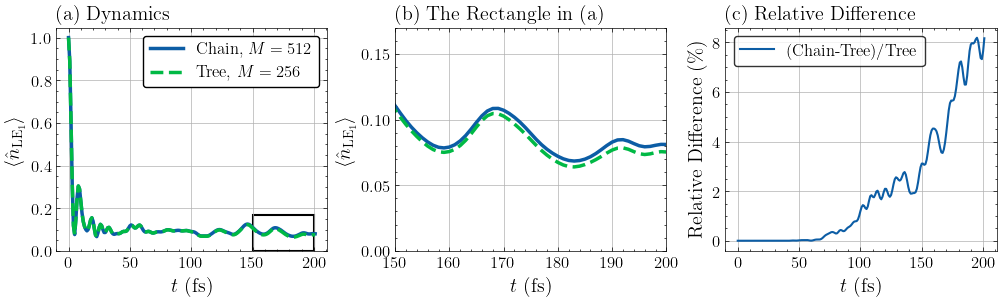

In [163]:
slide_ver = False

n1 = np.load("MPS.npz")["n"][np.load("MPS.npz")["M"].tolist().index(512), 0]
n2 = np.load("Tree5.npz")["n"][np.load("Tree5.npz")["M"].tolist().index("256"), 0]
n3 = np.load("ref.npy")[0]
n4 = np.load("ref.npy")[1]

fig, axs = plt.subplots(1, 3, figsize=(10, 3), layout="constrained")

plt.sca(axs[0])
if slide_ver:
    label_mps = "MPS (this work)"
    label_tree = "Tree (this work)"
else:
    label_mps = "Chain, $M=512$"
    label_tree = "Tree, $M=256$"    
plt.plot(n1, label=label_mps, linewidth=2.5)
plt.plot(n2, linestyle="--", label=label_tree, linewidth=2.5)
if slide_ver:
    plt.plot(n3, linestyle="-.", label=r"MPS (ref)")
    plt.plot(n4, linestyle=":", label=r"Tree (ref)")
plt.legend(facecolor="white", framealpha=1, frameon=True, edgecolor="black")
plt.xlabel("$t$ (fs)")
plt.ylabel(y_label_text)
plt.title("(a) Dynamics", loc="left")
plt.grid()
plt.ylim(0, None)
axs[0].add_patch(plt.Rectangle((150, 0), 50, 0.17, ls="-", ec="black", fc="none",linewidth=1.5))

plt.sca(axs[1])
plt.plot(n1, label="Chain (this work) $M=512$", linewidth=2.5)
plt.plot(n2, linestyle="--", label="Tree (this work), $M=256$", linewidth=2.5)
if slide_ver:
    plt.plot(n3, linestyle="-.", label=r"MPS (ref), $M_{\rm{max}}=400$")
    plt.plot(n4, linestyle=":", label=r"Tree (ref), $M_{\rm{max}}=40$")
#plt.legend(facecolor="white", framealpha=1, frameon=True, edgecolor="black")
plt.xlabel("$t$ (fs)")
plt.ylabel(y_label_text)
plt.title("(b) The Rectangle in (a)", loc="left")
plt.grid()
plt.xlim(150, 200)
plt.ylim(0, 0.17)



plt.sca(axs[2])
if slide_ver:
    label = "This work"
else:
    label = "(Chain-Tree)/Tree"
plt.plot((n1 - n2)/n2*100, label=label)
if slide_ver:
    plt.plot(np.arange(len(n4))[0:], ((n3 - n4)/n4*100)[0:], label="Ref", ls="--")
plt.legend()
plt.xlabel("$t$ (fs)")
plt.ylabel(r"Relative Difference (\%)")
plt.grid()
plt.title("(c) Relative Difference", loc="left")
if slide_ver:
    fname = "fig3-slide.pdf"
else:
    fname = "fig3.pdf"
plt.savefig(fname)

In APP. Fig B1: (1) decent convergence within MPS and Tree respectively. (2) MPS and Tree appears to be converging (checkout M=256). (3) TreeX has the fastest convergence speed.

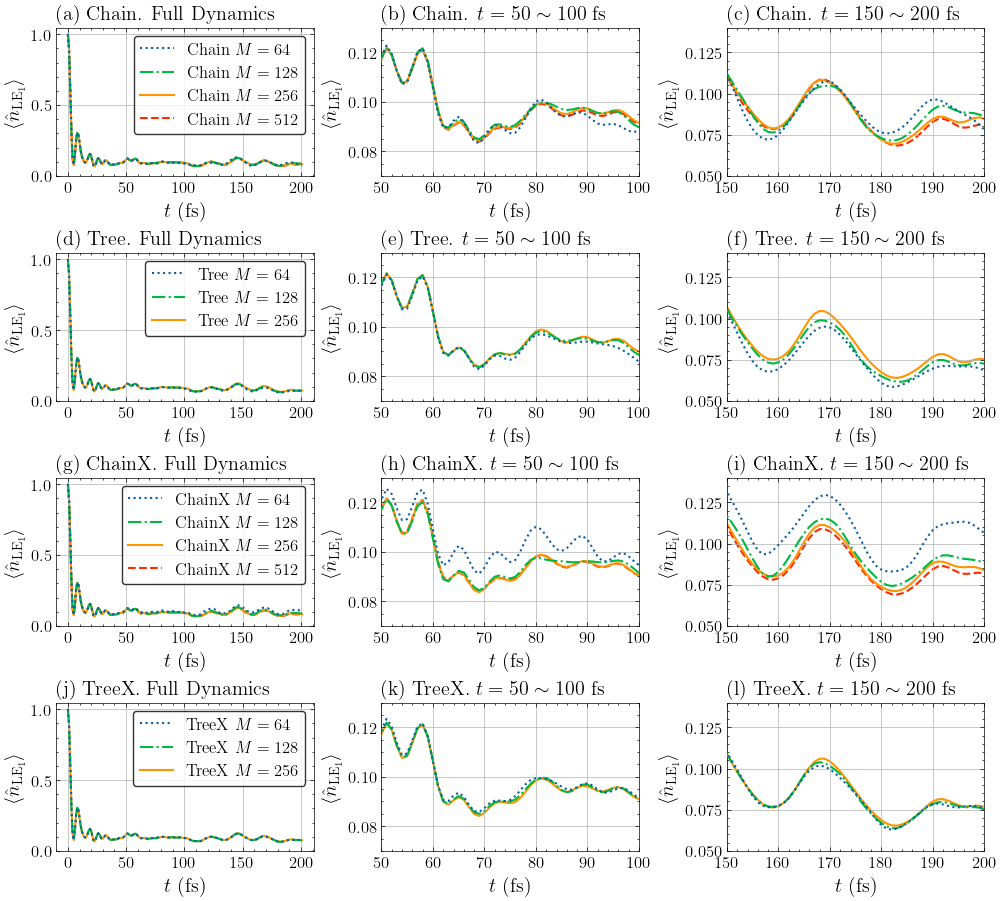

In [165]:
fig, axs = plt.subplots(4, 3, figsize=(10, 9), layout="constrained")
linestyles = [":", "-.", "-", "--"]
zorders = [100, 10, -10, -100]

xlims = [(None, None), (50, 100), (150, 200)]
ylims = [(0, None), (0.07, 0.13),  (0.05, 0.14)]

for l in range(4):
    if l == 0:
        npz = np.load("MPS.npz")
        m_list = [64, 128, 256, 512]
        label_prefix = "Chain"
        titles = ["(a) Chain. Full Dynamics", r"(b) Chain. $t=50 \sim 100$ fs", r"(c) Chain. $t=150\sim 200$ fs"]
    elif l == 1:
        npz = np.load("Tree5.npz")
        m_list = ["64", "128" ,"256"]
        label_prefix = "Tree"
        titles = ["(d) Tree. Full Dynamics", r"(e) Tree. $t=50 \sim 100$ fs", r"(f) Tree. $t=150\sim 200$ fs"]
    elif l == 2:
        npz = np.load("mps4.npz")
        m_list = [64, 128 ,256, 512]
        label_prefix = "ChainX"
        titles = ["(g) ChainX. Full Dynamics", r"(h) ChainX. $t=50 \sim 100$ fs", r"(i) ChainX. $t=150\sim 200$ fs"]
    else:
        assert l == 3
        npz = np.load("Tree4.npz")
        m_list = [64, 128 ,256]
        label_prefix = "TreeX"
        titles = ["(j) TreeX. Full Dynamics", r"(k) TreeX. $t=50 \sim 100$ fs", r"(l) TreeX. $t=150\sim 200$ fs"]
    
    for i in range(3):
        plt.sca(axs[l, i])
        for j, m in enumerate(m_list):
            k = npz["M"].tolist().index(m)
            plt.plot(npz["n"][k, 0], linestyle=linestyles[j], label=f"{label_prefix} $M={m}$", zorder=zorders[j])
        plt.xlim(*xlims[i])
        plt.ylim(*ylims[i])
        if i == 0:
            plt.legend(facecolor="white", frameon=True, edgecolor="black")
        plt.xlabel("$t$ (fs)")
        plt.ylabel(y_label_text)
        plt.title(titles[i], loc="left")
        plt.grid()

plt.savefig("figb1.pdf")
plt.show()

Extrapolation is possible. There are nonlinearty - sometimes it may fail

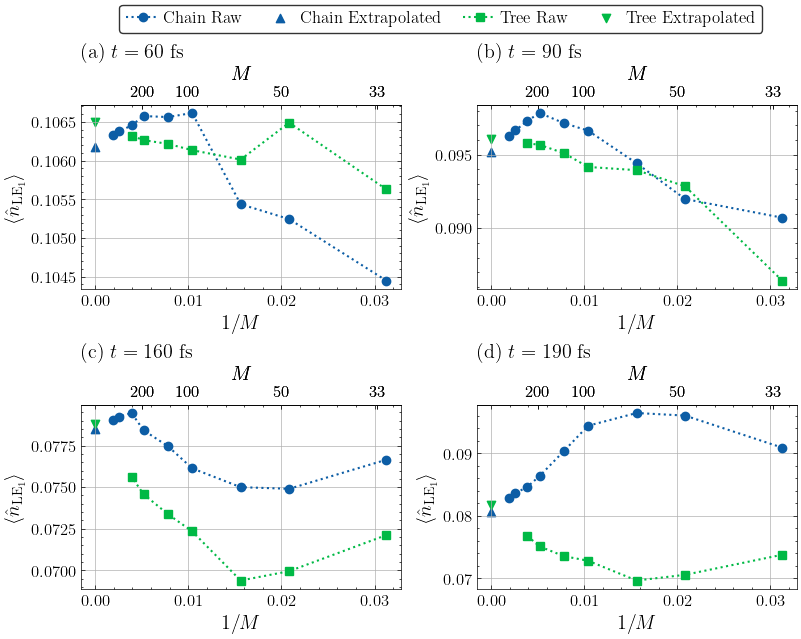

In [166]:
mps = np.load("MPS.npz")
tree1 = np.load("Tree5.npz")
ext = np.load("extrpolated_alldof2.npy")

M_list_mps = np.array([32, 48, 64, 96, 128, 192, 256, 384, 512])
M_list_tree = np.array([32, 48, 64, 96, 128, 192, 256])

fig, axs = plt.subplots(2, 2, figsize=(8, 6), layout="constrained")
axs = axs.ravel()
t_list = [60, 90, 160, 190]

markers = ["o", "s"]
markers2 = ["^", "v"]
lines = []
for j, t in enumerate(t_list):
    plt.sca(axs[j])
    
    for i, npz in enumerate([mps, tree1]):
        
        if i == 0:
            M_list = M_list_mps
        else:
            assert i == 1
            M_list = M_list_tree


        n_vs_M = []
        for k, m in enumerate(M_list):
            n_vs_M.append(npz["n"][list(map(str, npz["M"])).index(str(m)), 0, t])
        line, = plt.plot(1/M_list, n_vs_M, marker=markers[i], linestyle=":")
        lines.append(line)
        secax = plt.gca().secondary_xaxis('top', functions=(lambda x: 1/(x+1e-10), lambda x: 1/(x+1e-10)))
        secax.set_xlabel("$M$")
        secax.set_ticks([33, 50, 100, 200])
        line = plt.scatter([0], ext[0, i, t], marker=markers2[i])
        lines.append(line)

    plt.grid()
    
    #plt.xlim(0, None)
    plt.xlabel("$1/M$")
    plt.ylabel(y_label_text)
    plt.title(f"({chr(97+j)}) $t={t}$ fs", loc="left")

fig.legend(lines, ["Chain Raw", "Chain Extrapolated", "Tree Raw", "Tree Extrapolated"],loc="upper center",  # Position the legend at the top center
           bbox_to_anchor=(0.55, 1.07),  # Adjust the legend's position above the subplots
           ncol=4, columnspacing=1.3,handletextpad=0.2)

plt.savefig("fig4.pdf")
plt.show()

In [7]:
npz["n"].shape

(11, 26, 202)

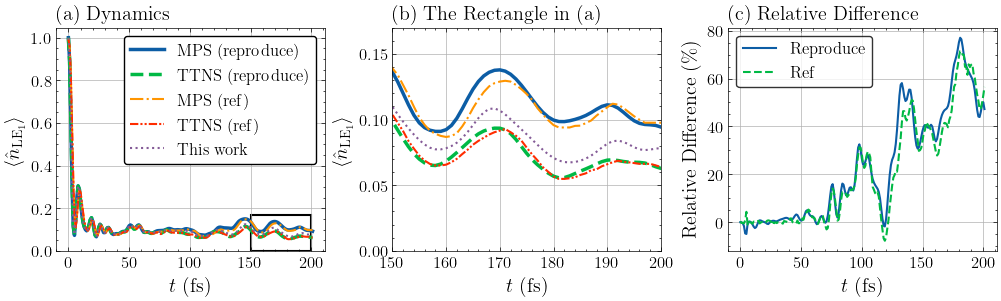

In [168]:
n1 = np.load("mps_M256_dt1_nb18_run2.npz")["n_le"]
n2 = np.load("Tree5.npz")["n"][np.load("Tree5.npz")["M"].tolist().index("mctdh"), 0]
n3 = np.load("ref.npy")[0]
n4 = np.load("ref.npy")[1]
n5 = np.load("extrpolated_alldof2.npy")[0].mean(axis=0)

fig, axs = plt.subplots(1, 3, figsize=(10, 3), layout="constrained")

plt.sca(axs[0])

label_mps = "MPS (reproduce)"
label_tree = "TTNS (reproduce)"

plt.plot(n1, label=label_mps, linewidth=2.5)
plt.plot(n2, linestyle="--", label=label_tree, linewidth=2.5)
plt.plot(n3, linestyle="-.", label=r"MPS (ref)")
plt.plot(n4, linestyle=(0, (4, 1, 1, 1, 1, 1)), label=r"TTNS (ref)")
plt.plot(n5, linestyle=":", label=r"This work")
plt.legend(facecolor="white", framealpha=1, frameon=True, edgecolor="black")
plt.xlabel("$t$ (fs)")
plt.ylabel(y_label_text)
plt.title("(a) Dynamics", loc="left")
plt.grid()
plt.ylim(0, None)

axs[0].add_patch(plt.Rectangle((150, 0), 50, 0.17, ls="-", ec="black", fc="none",linewidth=1.5))

plt.sca(axs[1])
plt.plot(n1, label="MPS (this work) $M=512$", linewidth=2.5)
plt.plot(n2, linestyle="--", label="TTNS (this work), $M=256$", linewidth=2.5)
plt.plot(n3, linestyle="-.", label=r"MPS (ref), $M_{\rm{max}}=400$")
plt.plot(n4, linestyle=(0, (4, 1, 1, 1, 1, 1)), label=r"Tree (ref), $M_{\rm{max}}=40$")
plt.plot(n5, linestyle=":")
#plt.legend(facecolor="white", framealpha=1, frameon=True, edgecolor="black")
plt.xlabel("$t$ (fs)")
plt.ylabel(y_label_text)
plt.title("(b) The Rectangle in (a)", loc="left")
plt.grid()
plt.xlim(150, 200)
plt.ylim(0, 0.17)


plt.sca(axs[2])

label = "Reproduce"

plt.plot((n1 - n2)/n2*100, label=label)
plt.plot(np.arange(len(n4))[0:], ((n3 - n4)/n4*100)[0:], label="Ref", ls="--")
plt.legend()
plt.xlabel("$t$ (fs)")
plt.ylabel(r"Relative Difference (\%)")
plt.grid()
plt.title("(c) Relative Difference", loc="left")
fname = "figc1.pdf"
plt.savefig(fname)

In [89]:
import colorsys
color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
color_cycle = [(int(c[1:3], 16)/255, int(c[3:5], 16)/255, int(c[5:7], 16)/255) for c in color_cycle]
colors = []
for i in [0, 1, 2, 3]:
    color = color_cycle[i]
    r,g,b = color
    h, s, v = colorsys.rgb_to_hsv(r,g,b)
    if s > 0.5:
        s = 0.5
    color = colorsys.hsv_to_rgb(h, s, v)
    colors.append(color)

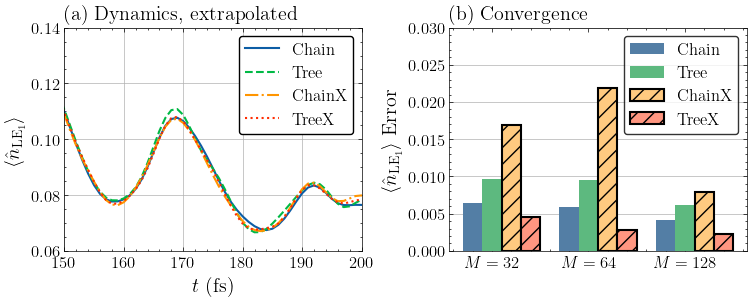

In [254]:
npz = np.load("extrpolated_alldof2.npy")

fig, axs = plt.subplots(1, 2, figsize=(7.5, 3), layout="constrained")
axs = axs.ravel()
labels = [ "Chain", "Tree","ChainX", "TreeX"  ]
linestyles = ["-", "--", "-.", ":"]
ylims = [[0.06, 0.06], [0.21, 0.06]]
y_labels = [y_label_text, r"$\langle \hat n_{\rm{CT_1}} \rangle$"]
titles = []
r = 0

n_ext = np.load("extrpolated_alldof2.npy")
ref = (n_ext[:, 0, :] + n_ext[:, 1, :] + n_ext[:, 2, :] + n_ext[:, 3, :]) / 4
fnames = ["./MPS.npz", "./Tree5.npz", "./mps4.npz", "./Tree4.npz"]

# plot extra: MPS and Tree, very small error, TreeX has higher error
#m_list = [32, 64, 128, "extra"]
m_list = [32, 64, 128]
tree_types = ["Chain", "Tree", "ChainX", "TreeX"]
error_list = []

for tree_type, fname in zip(tree_types, fnames):
    for m in m_list:
        npz = np.load(fname)
        i = npz["M"].astype(str).tolist().index(str(m))
        n = npz["n"][i]
        #error = np.abs(n - ref).mean(axis=0)
        dof = 0
        error = np.abs(n - ref)[dof]
        error50 = error[50:100].mean()
        error150 = error[150:200].mean()
        error_list.append(error50)
        error_list.append(error150)
# dimensions: tree_type, M, time
error_list = np.array(error_list).reshape(len(fnames), len(m_list), 2)


plt.sca(axs[1])
width = 0.2
plt.grid(zorder=-100, axis="y")
i = 1
plt.bar(np.arange(len(m_list))-width, error_list[0, :, i], width=width, label="Chain", zorder=10, color=colors[0])
plt.bar(np.arange(len(m_list)), error_list[1, :, i], width=width, label="Tree", zorder=10, color=colors[1])
plt.bar(np.arange(len(m_list))+width, error_list[2, :, i], width=width, label="ChainX", zorder=10, color=colors[2], hatch="//", edgecolor="black", linewidth=1.5)
plt.bar(np.arange(len(m_list))+2*width, error_list[3, :, i], width=width, label="TreeX", zorder=10, color=colors[3], hatch="//", edgecolor="black", linewidth=1.5)
plt.legend()
plt.xticks(np.arange(len(m_list)), [f"$M={m}$" for m in m_list])
plt.ylabel(r"$\langle \hat n_{\rm{LE_1}} \rangle$ Error")
plt.title("(b) Convergence",loc="left")
plt.ylim(0, 0.03)

npz = np.load("extrpolated_alldof2.npy")
plt.sca(axs[0])
for j in range(4):
    plt.plot(npz[r, j, :], label=labels[j], ls=linestyles[j])

plt.xlabel("$t$ (fs)")
plt.ylabel(y_labels[r])
plt.grid()
plt.xlim(150, 200)
plt.legend(facecolor="white", framealpha=1, frameon=True, edgecolor="black")
plt.ylim(0.06, 0.14)
plt.title("(a) Dynamics, extrapolated", loc="left")


plt.savefig("fig7.pdf")
plt.show()

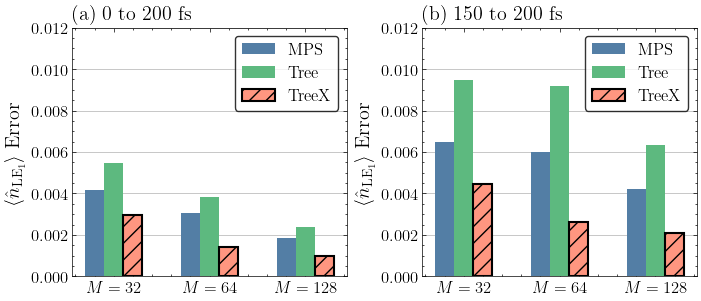

In [21]:
npz = np.load("extrpolated_alldof2.npy")

fig, axs = plt.subplots(1, 2, figsize=(7, 3), layout="constrained")
labels = [ "MPS, extrapolated", "Tree, extrapolated","TreeX, extrapolated"  ]
linestyles = ["-", "--", "-."]
ylims = [[0.06, 0.06], [0.21, 0.06]]
y_labels = [y_label_text, r"$\langle \hat n_{\rm{CT_1}} \rangle$"]
titles = []
r = 0



n_ext = np.load("extrpolated_alldof2.npy")
ref = (n_ext[:, 0, :] + n_ext[:, 1, :] + n_ext[:, 2, :]) / 3
fnames = ["./MPS.npz", "./Tree1.npz", "./Tree4.npz"]

# plot extra: MPS and Tree, very small error, TreeX has higher error
#m_list = [32, 64, 128, "extra"]
m_list = [32, 64, 128]
tree_types = ["MPS", "Tree", "TreeX"]
error_list = []

for tree_type, fname in zip(tree_types, fnames):
    for m in m_list:
        npz = np.load(fname)
        i = npz["M"].tolist().index(m)
        n = npz["n"][i]
        #error = np.abs(n - ref).mean(axis=0)
        dof = 0
        error = np.abs(n - ref)[dof]
        error50 = error.mean()
        error150 = error[150:200].mean()
        error_list.append(error50)
        error_list.append(error150)
# dimensions: tree_type, M, time
error_list = np.array(error_list).reshape(len(fnames), len(m_list), 2)

titles = ["(a) 0 to 200 fs", "(b) 150 to 200 fs"]
for i in range(2):

    plt.sca(axs[i])
    width = 0.2
    plt.grid(zorder=-100, axis="y")
    plt.bar(np.arange(len(m_list))-width, error_list[0, :, i], width=width, label="MPS", zorder=10, color=colors[0])
    plt.bar(np.arange(len(m_list)), error_list[1, :, i], width=width, label="Tree", zorder=10, color=colors[1])
    plt.bar(np.arange(len(m_list))+width, error_list[2, :, i], width=width, label="TreeX", zorder=10, color=colors[2], hatch="//", edgecolor="black", linewidth=1.5)
    plt.legend()
    plt.xticks(np.arange(len(m_list)), [f"$M={m}$" for m in m_list])
    plt.ylabel(r"$\langle \hat n_{\rm{LE_1}} \rangle$ Error")
    plt.title(titles[i],loc="left")
    plt.ylim(0, 0.012)


plt.savefig("response-window.pdf")
plt.show()

In [14]:
npz = np.load("Tree1.npz")
npz["entropy"].shape

(11, 202, 246)

Tree and MPS is actually the same?
from (a) we know the bottleneck is the S between OT modes and the rest of the system. So we put the otmodes and the rest of the system together in the subtrees.

Convergence for S is most difficult. (cf. appendix convergence)

Tree has lower S in  the short time, but grows at the long time.

TreeX has lower S and thus higher accuracy.

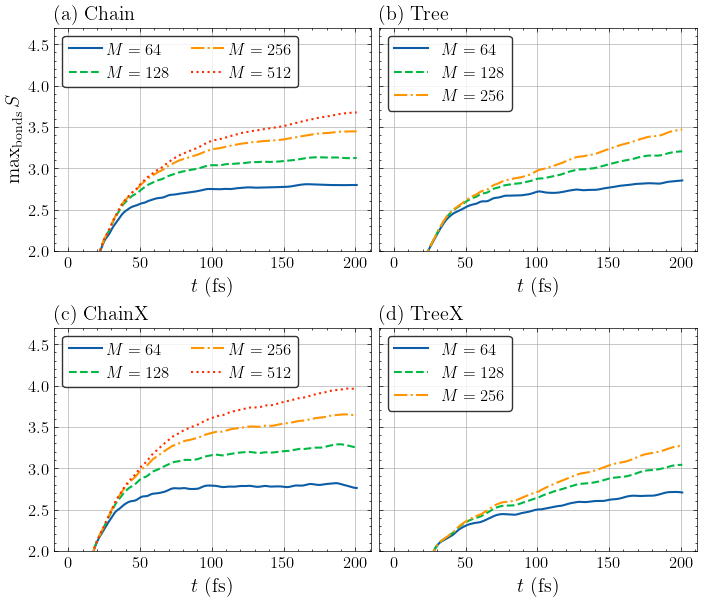

In [172]:
fig, axs = plt.subplots(2, 2, figsize=(7, 6), layout="constrained", sharey=True)
axs = axs.ravel()
m_list_list = [[64, 128, 256, 512], [64, 128, 256], [64, 128, 256, 512], [64, 128, 256]]
linestyles = ["-", "--", "-.", ":", ]
fnames = ["MPS.npz", "Tree5.npz", "mps4.npz", "Tree4.npz"]
titles = ["(a) Chain", "(b) Tree", "(c) ChainX", "(d) TreeX"]
entropy_idx_list = []
for i in range(4):
    plt.sca(axs[i])
    npz = np.load(fnames[i])
    for j in range(len(m_list_list[i])):
        m_idx = npz["M"].astype(str).tolist().index(str(m_list_list[i][j]))
        entropy = npz["entropy"][m_idx]
        plt.plot(np.max(entropy, axis=1), ls=linestyles[j], label=f"$M={m_list_list[i][j]}$")
    entropy_idx_list.append(np.argmax(entropy, axis=1))
    if i in [0, 2]:
        plt.legend(loc="upper left", ncol=2,columnspacing=1.3,handletextpad=0.2)
    else:
        plt.legend(loc="upper left", ncol=1)
    
    plt.xlabel("$t$ (fs)")
    if i == 0:
        plt.ylabel(r"$\max_{\textrm{bonds}}S$")
    plt.title(titles[i], loc="left")
    plt.grid()
plt.ylim(2, 4.7)
plt.savefig("fig8.pdf")
plt.show()

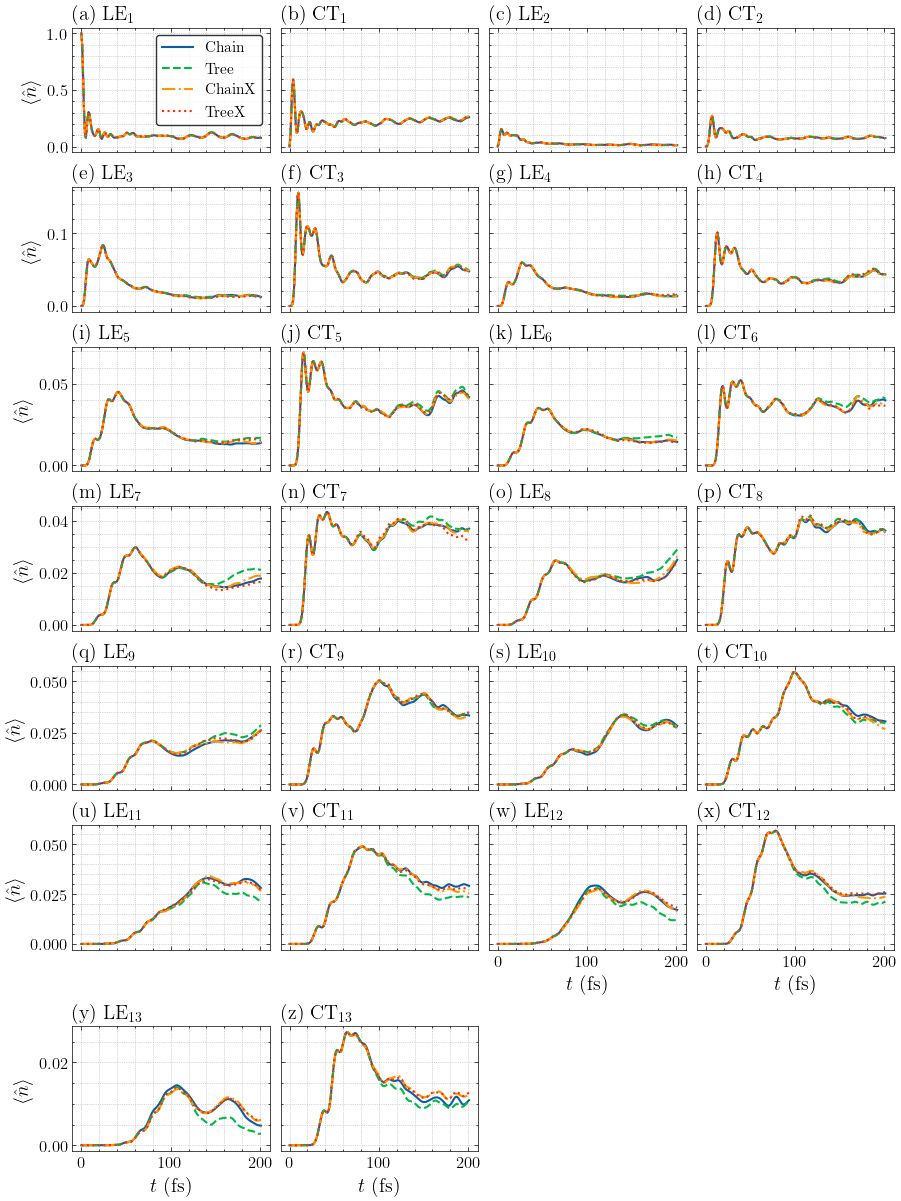

In [277]:
npz = np.load("extrpolated_alldof2.npy")

fig, axs = plt.subplots(7, 4, figsize=(9, 12), sharex=True, sharey="row", layout="constrained")
#plt.subplots_adjust(hspace=0.5)
axs = axs.ravel()
labels = ["Chain", "Tree", "ChainX", "TreeX"]
linestyles = ["-", "--", "-.", ":", ]

for i in range(26):
    plt.sca(axs[i])
    if i % 2 == 0:
        title = r"LE$_{" + str(i//2+1)  + "}$"
    else:
        title = r"CT$_{" + str(i//2+1)  + "}$"
    lines = []
    for j in range(4):
        line, = plt.plot(npz[i, j, :], ls=linestyles[j], label=labels[j])
        lines.append(line)
    #plt.ylabel(r"Absolute Difference")
    plt.title(f"({chr(97+i)}) {title}", loc="left")
    plt.grid(which="both", ls=":")
    if i % 4 == 0:
        plt.ylabel(r"$\langle \hat n \rangle$")
    if i == 0:
        plt.legend(fontsize=11)

for i in list(range(22, 26)):
    plt.sca(axs[i])
    plt.xlabel("$t$ (fs)")
for i in [22, 23]:
    axs[i].tick_params(bottom=True, labelbottom=True)

for i in range(26, 28):
    axs[i].axis("off")

#plt.legend()
#fig.text(0.03, 0.5, r"$\langle \hat n \rangle$ Difference", va='center', rotation='vertical', fontsize="x-large")

#fig.legend(lines, ["MPS", "Tree", "TreeX"], # Position the legend at the top center
#           bbox_to_anchor=(0.9,0.22),  # Adjust the legend's position above the subplots
#           )

#plt.savefig("test.pdf")
#plt.tight_layout()
plt.savefig("figd1.pdf")
plt.show()

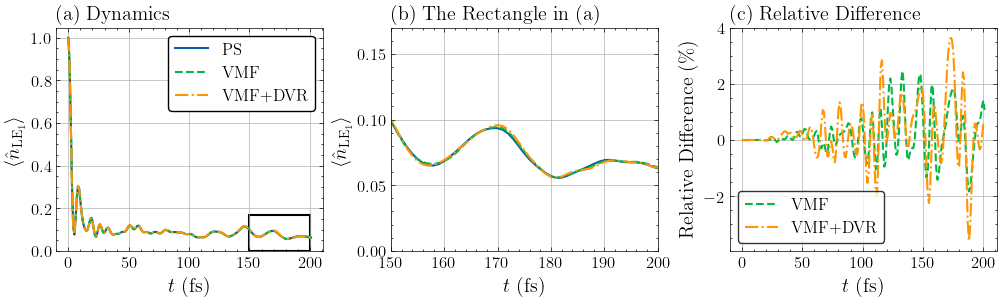

In [17]:
slide_ver = False

npz = np.load("Tree5.npz")

n1 = npz["n"][npz["M"].tolist().index("mctdh"), 0]
n2 = npz["n"][npz["M"].tolist().index("mctdh-vmf"), 0]
n3 = npz["n"][npz["M"].tolist().index("mctdh-vmf-dvr"), 0]


fig, axs = plt.subplots(1, 3, figsize=(10, 3), layout="constrained")

plt.sca(axs[0])

plt.plot(n1, label="PS")
plt.plot(n2, linestyle="--", label="VMF")
plt.plot(n3,  linestyle="-.", label="VMF+DVR")
plt.legend(facecolor="white", framealpha=1, frameon=True, edgecolor="black")
plt.xlabel("$t$ (fs)")
plt.ylabel(y_label_text)
plt.title("(a) Dynamics", loc="left")
plt.grid()
plt.ylim(0, None)
axs[0].add_patch(plt.Rectangle((150, 0), 50, 0.17, ls="-", ec="black", fc="none",linewidth=1.5))

plt.sca(axs[1])
plt.plot(n1, label="PS")
plt.plot(n2, linestyle="--", label="VMF")
plt.plot(n3,  linestyle="-.", label="VMF+DVR")
#plt.legend(facecolor="white", framealpha=1, frameon=True, edgecolor="black")
plt.xlabel("$t$ (fs)")
plt.ylabel(y_label_text)
plt.title("(b) The Rectangle in (a)", loc="left")
plt.grid()
plt.xlim(150, 200)
plt.ylim(0, 0.17)



plt.sca(axs[2])
plt.plot(0, 0)
plt.plot((n2 - n1)/n1*100, label="VMF", linestyle="--")
plt.plot((n3 - n1)/n1*100, label="VMF+DVR", linestyle="-.")
plt.legend()
plt.xlabel("$t$ (fs)")
plt.ylabel(r"Relative Difference (\%)")
plt.grid()
plt.title("(c) Relative Difference", loc="left")

plt.savefig("Figc3.pdf")

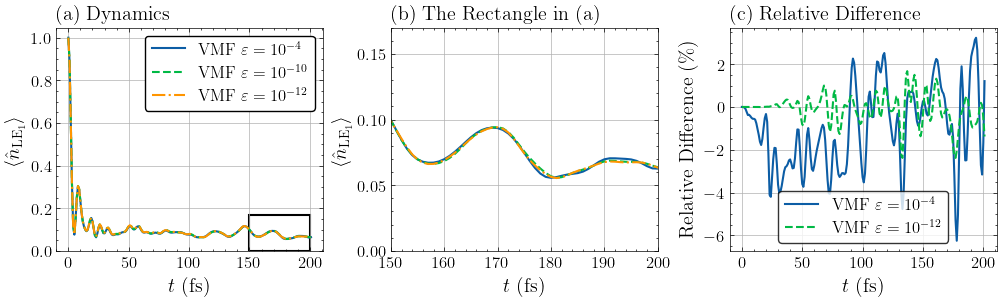

In [276]:
slide_ver = False

npz = np.load("Tree5.npz")

n1 = npz["n"][npz["M"].tolist().index("mctdh-vmf4"), 0]
label1 = r"VMF $\varepsilon=10^{-4}$"
label2 = r"VMF $\varepsilon=10^{-10}$"
label3 = r"VMF $\varepsilon=10^{-12}$"
n2 = npz["n"][npz["M"].tolist().index("mctdh-vmf"), 0]
n3 = npz["n"][npz["M"].tolist().index("mctdh-vmf12"), 0]


fig, axs = plt.subplots(1, 3, figsize=(10, 3), layout="constrained")

plt.sca(axs[0])


plt.plot(n1, label=label1)
plt.plot(n2, linestyle="--", label=label2)
plt.plot(n3,  linestyle="-.", label=label3)
plt.legend(facecolor="white", framealpha=1, frameon=True, edgecolor="black")
plt.xlabel("$t$ (fs)")
plt.ylabel(y_label_text)
plt.title("(a) Dynamics", loc="left")
plt.grid()
plt.ylim(0, None)
axs[0].add_patch(plt.Rectangle((150, 0), 50, 0.17, ls="-", ec="black", fc="none",linewidth=1.5))

plt.sca(axs[1])
plt.plot(n1, label=label1)
plt.plot(n2, linestyle="--", label=label2)
plt.plot(n3,  linestyle="-.", label=label3)
#plt.legend(facecolor="white", framealpha=1, frameon=True, edgecolor="black")
plt.xlabel("$t$ (fs)")
plt.ylabel(y_label_text)
plt.title("(b) The Rectangle in (a)", loc="left")
plt.grid()
plt.xlim(150, 200)
plt.ylim(0, 0.17)



plt.sca(axs[2])
plt.plot((n1 - n2)/n3*100, label=label1, linestyle="-")
#plt.plot(0, 0)
plt.plot((n3 - n2)/n3*100, label=label3, linestyle="--")
plt.legend()
plt.xlabel("$t$ (fs)")
plt.ylabel(r"Relative Difference (\%)")
plt.grid()
plt.title("(c) Relative Difference", loc="left")

plt.savefig("Figc4.pdf")

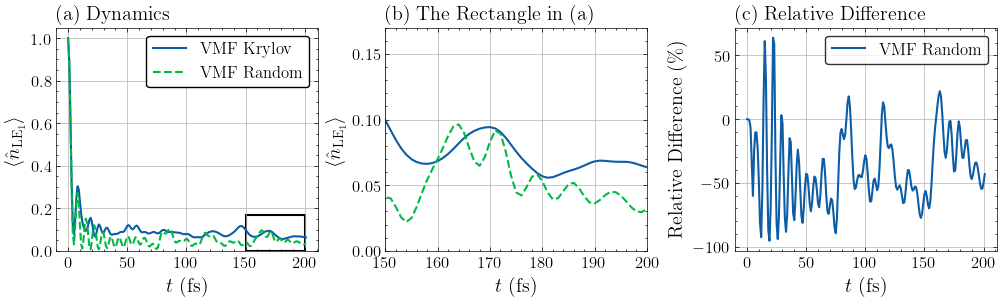

In [159]:
slide_ver = False

npz = np.load("Tree5.npz")

n1 = npz["n"][npz["M"].tolist().index("mctdh-vmf"), 0]
label1 = r"VMF Krylov"
label2 = r"VMF Random"
n2 = npz["n"][npz["M"].tolist().index("mctdh-vmf-random"), 0]


fig, axs = plt.subplots(1, 3, figsize=(10, 3), layout="constrained")

plt.sca(axs[0])


plt.plot(n1, label=label1)
plt.plot(n2, linestyle="--", label=label2)
plt.legend(facecolor="white", framealpha=1, frameon=True, edgecolor="black")
plt.xlabel("$t$ (fs)")
plt.ylabel(y_label_text)
plt.title("(a) Dynamics", loc="left")
plt.grid()
plt.ylim(0, None)
axs[0].add_patch(plt.Rectangle((150, 0), 50, 0.17, ls="-", ec="black", fc="none",linewidth=1.5))

plt.sca(axs[1])
plt.plot(n1, label=label1)
plt.plot(n2, linestyle="--", label=label2)
#plt.legend(facecolor="white", framealpha=1, frameon=True, edgecolor="black")
plt.xlabel("$t$ (fs)")
plt.ylabel(y_label_text)
plt.title("(b) The Rectangle in (a)", loc="left")
plt.grid()
plt.xlim(150, 200)
plt.ylim(0, 0.17)



plt.sca(axs[2])
plt.plot((n2 - n1)/n1*100, label=label2, linestyle="-")
plt.legend()
plt.xlabel("$t$ (fs)")
plt.ylabel(r"Relative Difference (\%)")
plt.grid()
plt.title("(c) Relative Difference", loc="left")

In [260]:
fnames = ["./MPS.npz", "./Tree5.npz", "./mps4.npz", "./Tree4.npz"]
M_list = [512, "256", 512, 256]
n_list = []
for fname, M in zip(fnames, M_list):
    npz = np.load(fname)
    n = npz["n"][npz["M"].tolist().index(M)]
    n_list.append(n)
ref = np.mean(n_list, axis=0)

[ 64  96 128 192 256]
[ 15.895  28.765  51.325 157.825 266.905]
[0.005938895972818947, 0.004706931173922182, 0.004116549995625572, 0.0030512826497508987, 0.0024606657170777287]
[ 32  48  64  96 128 192]
[ 13.705  15.435  29.845  36.83   96.295 384.8  ]
[0.009699308245920114, 0.009393992200386704, 0.00951561157247855, 0.007486075642977821, 0.006186236128673943, 0.004411305667637469]
[ 64  96 128 192 256 384]
[  9.88   18.96   32.47   83.405 177.5   447.425]
[0.021873214955281908, 0.00938501847300839, 0.007929068295699226, 0.005220116066087597, 0.004242869706828571, 0.002576509392463977]
[ 32  48  64  96 128 192]
[ 12.195  14.935  26.77   53.43  126.51  486.66 ]
[0.004507641136400954, 0.003774664692668222, 0.0027568156271929665, 0.002524230856730457, 0.0022215838111334578, 0.0017252247821553219]


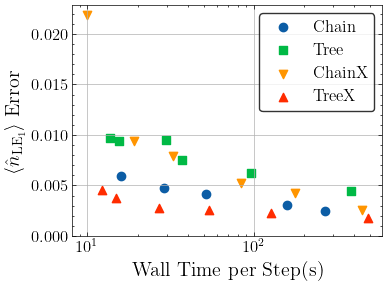

In [274]:
n_ext = np.load("extrpolated_alldof2.npy")
ref = (n_ext[:, 0, :] + n_ext[:, 1, :] + n_ext[:, 2, :] + n_ext[:, 3, :]) / 4

fnames = ["./MPS.npz", "./Tree5.npz", "./mps4.npz", "./Tree4.npz"]
tree_types = ["Chain", "Tree", "ChainX", "TreeX"]
markers = ["o", "s", "v", "^"]

for j, (tree_type, fname) in enumerate(zip(tree_types, fnames)):
    
    error_list = []
    
    npz = np.load(fname)
    time_list = npz["dts_list"][:, 0]
    m_list = []
    for m in npz["M"]:
        if "mctdh" not in str(m):
            m_list.append(int(m))
        else:
            m_list.append(0)
    m_list = np.array(m_list)
    if tree_type in ["Chain"]:
        index = (64 <= m_list) & (m_list <= 256)
    elif tree_type in ["ChainX"]:
        index = (64 <= m_list) & (m_list <= 384)
    elif tree_type == "Tree":
        index = (32 <= m_list) & (m_list <= 192)
    else:
        assert tree_type == "TreeX"
        index = (32 <= m_list) & (m_list <= 192)
    
    for n in npz["n"][index]:
        #error = np.abs(n - ref).mean(axis=0)
        error = np.abs(n - ref)[0]
        error150 = error[150:200].mean()
        error_list.append(error150)
    print(m_list[index])
    print(np.array(time_list)[index])
    print(error_list)
    plt.scatter(np.array(time_list)[index], error_list, label=tree_type, marker=markers[j])

plt.xscale("log")
plt.legend()
plt.ylim(0, None)
plt.grid(zorder=-100)
plt.xlabel("Wall Time per Step(s)")
plt.ylabel(r"$\langle \hat n_{\rm{LE_1}} \rangle$ Error")
plt.savefig("fig9.pdf")

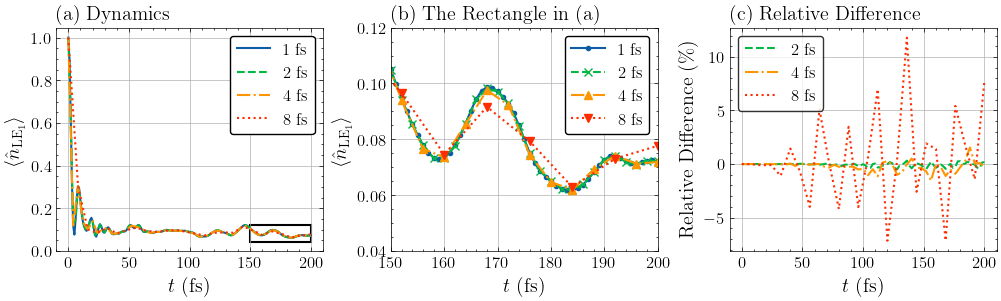

In [133]:
npz = np.load("dt.npz")
dt_strs = ["1", "2", "4", "8"]

fig, axs = plt.subplots(1, 3, figsize=(10, 3), layout="constrained")



plt.sca(axs[0])

label_mps = "MPS (reproduce)"
label_tree = "Tree (reproduce)"

linestyles = ["-", "--", "-.", ":"]
markers = [".", "x", "^", "v"]
for i, dt in enumerate(dt_strs):
    plt.plot(npz[dt][0], npz[dt][1], label=f"{dt} fs", linestyle=linestyles[i])
plt.legend(facecolor="white", framealpha=1, frameon=True, edgecolor="black")
plt.xlabel("$t$ (fs)")
plt.ylabel(y_label_text)
plt.title("(a) Dynamics", loc="left")
plt.grid()
plt.ylim(0, None)

axs[0].add_patch(plt.Rectangle((150, 0.04), 50, 0.08, ls="-", ec="black", fc="none",linewidth=1.5))

plt.sca(axs[1])
linestyles = ["-", "--", "-.", ":"]
markers = [".", "x", "^", "v"]
for i, dt in enumerate(dt_strs):
    plt.plot(npz[dt][0], npz[dt][1], label=f"{dt} fs", linestyle=linestyles[i], marker=markers[i])
plt.legend(facecolor="white", framealpha=1, frameon=True, edgecolor="black")
plt.xlabel("$t$ (fs)")
plt.ylabel(y_label_text)
plt.title("(b) The Rectangle in (a)", loc="left")
plt.grid()
plt.xlim(150, 200)
plt.ylim(0.04, 0.12)


plt.sca(axs[2])


linestyles = ["-", "--", "-.", ":"]
markers = [".", "x", "^", "v"]
dump_dict = {}
for i, dt in enumerate(dt_strs):
    if i == 0:
        plt.plot([0], [0], marker=None)
        continue
    mask = [npz["1"][0].tolist().index(t) for t in npz[dt][0]]
    plt.plot(npz[dt][0], (npz[dt][1] - npz["1"][1][mask])/ npz["1"][1][mask]*100, label=f"{dt} fs", linestyle=linestyles[i])
plt.legend()
plt.xlabel("$t$ (fs)")
plt.ylabel(r"Relative Difference (\%)")
plt.grid()
plt.title("(c) Relative Difference", loc="left")
fname = "figb2.pdf"
plt.savefig(fname)